<div style="background:linear-gradient(135deg,#1B5E20 0%,#1565C0 50%,#4A148C 100%);
padding:42px 36px;border-radius:14px;color:white;font-family:'Segoe UI',sans-serif">
<h1 style="font-size:2.4em;margin:0;letter-spacing:-0.5px">🌾 East African Agriculture</h1>
<h2 style="font-size:1.4em;margin:8px 0 0;font-weight:400;opacity:0.9">Food Security &amp; Crop Production Analysis — FAOSTAT 2004–2024</h2>
<hr style="border:none;border-top:1px solid rgba(255,255,255,0.35);margin:18px 0"/>
<div style="display:flex;gap:40px;flex-wrap:wrap;font-size:0.95em;opacity:0.88">
<div>📁 <b>Dataset:</b> FAOSTAT Crops &amp; Livestock Products</div>
<div>🌍 <b>Countries:</b> Ethiopia · Kenya · Uganda · South Sudan</div>
<div>📅 <b>Period:</b> 2004–2024 (20 years)</div>
<div>📊 <b>Records:</b> 13,767 observations · 120 crop types</div>
</div></div>


---
## 1 · Setup & Data Loading
> **Goal:** Load the raw FAO dataset, remove invalid observations (Flag=M), convert data types, and standardise crop names for readable analysis.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Consistent colour palette per country
PALETTE = {
    "Ethiopia":    "#2E7D32",  # forest green
    "Kenya":       "#1565C0",  # deep blue
    "Uganda":      "#E65100",  # burnt orange
    "South Sudan": "#6A1B9A",  # purple
}
COUNTRIES = list(PALETTE.keys())

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.facecolor": "#FAFAFA", "figure.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
})



In [4]:
df_raw = pd.read_csv("FAOSTAT_data_en_3-15-2026.csv", encoding="utf-8-sig")
df_raw.columns = df_raw.columns.str.strip()
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)


Raw shape: (13767, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,231,Ethiopia,5312,Area harvested,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2004,2004,ha,1440.0,E,Estimated value,NaN
1,QCL,Crops and livestock products,231,Ethiopia,5412,Yield,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2004,2004,kg/ha,625.0,E,Estimated value,NaN
2,QCL,Crops and livestock products,231,Ethiopia,5510,Production,01654,"Anise, badian, coriander, cumin, caraway, fenn...",2004,2004,t,900.0,E,Estimated value,NaN


In [11]:
# Remove missing by definition (Flag=M) and NaN values
df = df_raw[df_raw["Flag"] != "M"].copy()
df = df.dropna(subset=["Value"])
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.dropna(subset=["Value"])

# Readable crop names
crop_rename = {
    "Maize (corn)": "Maize",
    "Cassava, fresh": "Cassava",
    "Plantains and cooking bananas": "Bananas",
    "Beans, dry": "Beans",
    "Sweet potatoes": "Sweet Potatoes",
    "Groundnuts, excluding shelled": "Groundnuts",
    "Coffee, green": "Coffee",
    "Tea leaves": "Tea",
    "Sugar cane": "Sugar Cane",
    "Cereals n.e.c.": "Other Cereals",
    "Other vegetables, fresh n.e.c.": "Other Vegetables",
    "Onions and shallots, dry (excluding dehydrated)": "Onions",
    "Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw": "Chillies",
}
df["Item"] = df["Item"].replace(crop_rename)

prod = df[df["Element"] == "Production"].copy()
area = df[df["Element"] == "Area harvested"].copy()
yld  = df[df["Element"] == "Yield"].copy()

print(f"   Clean dataset: {df.shape[0]:,} rows ({df_raw.shape[0]-df.shape[0]:,} dropped)")
print(f"   Production: {len(prod):,}  |  Area: {len(area):,}  |  Yield: {len(yld):,}")
print(f"   Years: {df.Year.min()}–{df.Year.max()}  |  Crops: {df.Item.nunique()}")


   Clean dataset: 13,659 rows (108 dropped)
   Production: 5,033  |  Area: 4,314  |  Yield: 4,312
   Years: 2004–2024  |  Crops: 119


---
## 2 · Exploratory Data Analysis
> Before visualising, we inspect data quality flags, statistical distributions, and country-level summaries.


In [12]:
# Flag distribution — data quality audit
flag_df = (
    df[["Flag","Flag Description"]].drop_duplicates()
    .set_index("Flag")
    .join(df["Flag"].value_counts().rename("Count"))
    .assign(Pct=lambda x: (x["Count"]/len(df)*100).round(1))
    .reset_index()
)
flag_df.columns = ["Flag","Description","Count","% of data"]
print("Data Quality Audit:")
flag_df


Data Quality Audit:


,Flag,Description,Count,% of data
0,E,Estimated value,4424,32.4
1,I,Value imputed by a receiving agency,2541,18.6
2,A,Official figure,5888,43.1
3,X,Figure from external organization,806,5.9


In [13]:
# Production summary by country
summary = (
    prod.groupby("Area")["Value"]
    .agg(Records="count", Total_t="sum", Mean_t="mean", Median_t="median", Std_t="std")
    .assign(
        Total_Mt = lambda x: (x.Total_t/1e6).round(2),
        Mean_kt  = lambda x: (x.Mean_t/1e3).round(1),
    )
    .reset_index()
)
print("Production Summary by Country (all years):")
summary[["Area","Records","Total_Mt","Mean_kt","Std_t"]].rename(
    columns={"Area":"Country","Total_Mt":"Total (Mt)","Mean_kt":"Mean (kt)","Std_t":"Std Dev (t)"})


Production Summary by Country (all years):


,Country,Records,Total (Mt),Mean (kt),Std Dev (t)
0,Ethiopia,1734,818.49,472.0,1.273994e+06
1,Kenya,2002,514.80,257.1,7.901385e+05
2,South Sudan,327,47.81,146.2,2.824765e+05
3,Uganda,970,532.08,548.5,1.451880e+06


In [14]:
# Top 10 crops by total production
top10 = (
    prod.groupby("Item")["Value"].sum()
    .sort_values(ascending=False).head(10).reset_index()
)
top10["Production (Mt)"] = (top10["Value"]/1e6).round(2)
top10["Share (%)"] = (top10["Value"]/top10["Value"].sum()*100).round(1)
top10.rename(columns={"Item":"Crop"})[["Crop","Production (Mt)","Share (%)"]]


,Crop,Production (Mt),Share (%)
0,Maize,296.54,21.8
1,Sugar Cane,247.35,18.2
2,Bananas,198.71,14.6
3,Sorghum,101.72,7.5
4,Potatoes,99.85,7.3
5,Cassava,97.96,7.2
6,Wheat,94.92,7.0
7,Other Cereals,91.54,6.7
8,Sweet Potatoes,83.92,6.2
9,Tea,47.24,3.5


---
## 3 · Key Performance Indicators
> Country-level summary for 20 years of agricultural output.


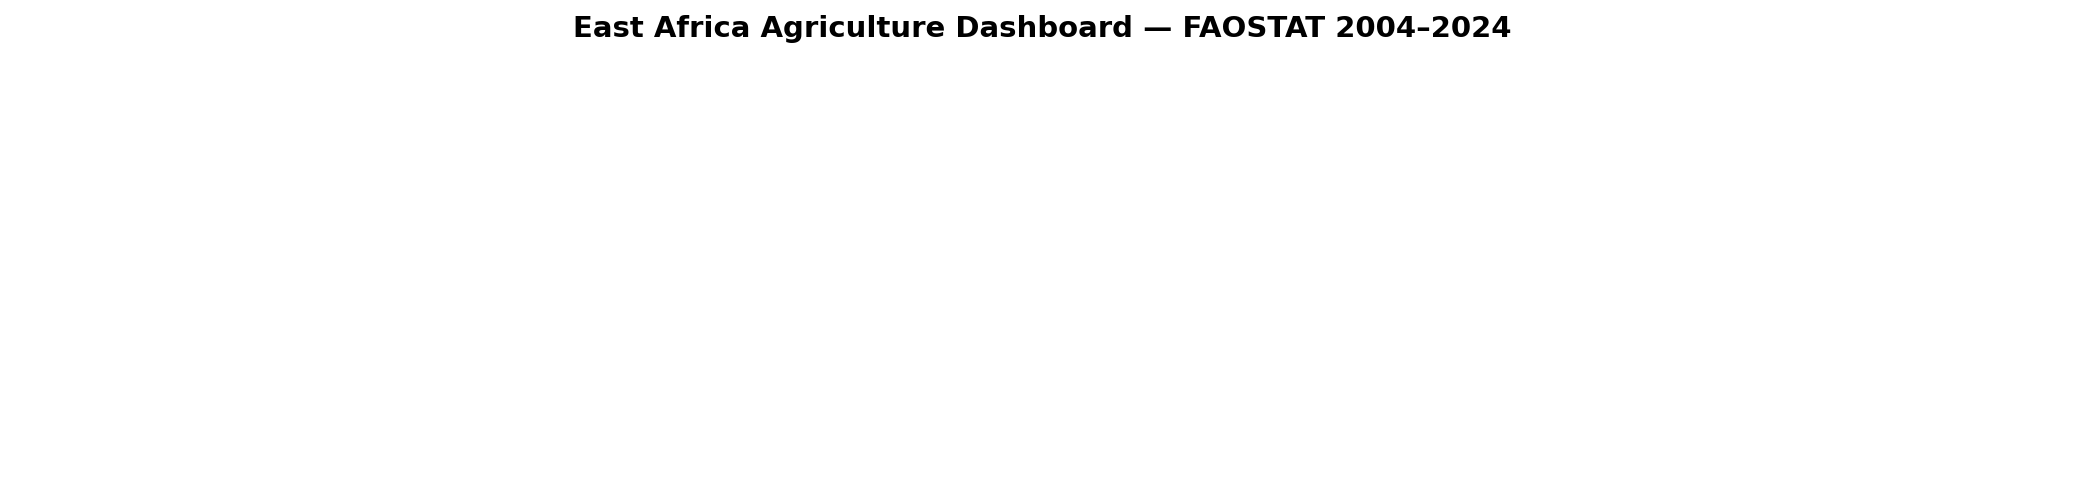<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 1 — Total Production KPIs per Country (2004–2024)</p>


---
## 4 · Production Trends 2004–2024
> **Key finding:** Ethiopia consistently leads; Uganda and Kenya show steady growth. South Sudan's output is volatile — reflecting the impact of civil conflict and climate shocks.


In [15]:
yr_country = prod.groupby(["Year","Area"])["Value"].sum().reset_index()
yr_country["Value_Mt"] = yr_country["Value"] / 1e6

# CAGR Ethiopia
eth = yr_country[yr_country["Area"]=="Ethiopia"].sort_values("Year")
cagr_eth = ((eth.iloc[-1]["Value_Mt"]/eth.iloc[0]["Value_Mt"])**(1/20)-1)*100
print(f"Ethiopia CAGR (2004–2024): {cagr_eth:.1f}% per year")
eth.tail(5)[["Year","Value_Mt"]].round(2)


Ethiopia CAGR (2004–2024): 5.1% per year


,Year,Value_Mt
56,2020,55.18
60,2021,54.57
64,2022,51.40
68,2023,52.08
72,2024,50.50


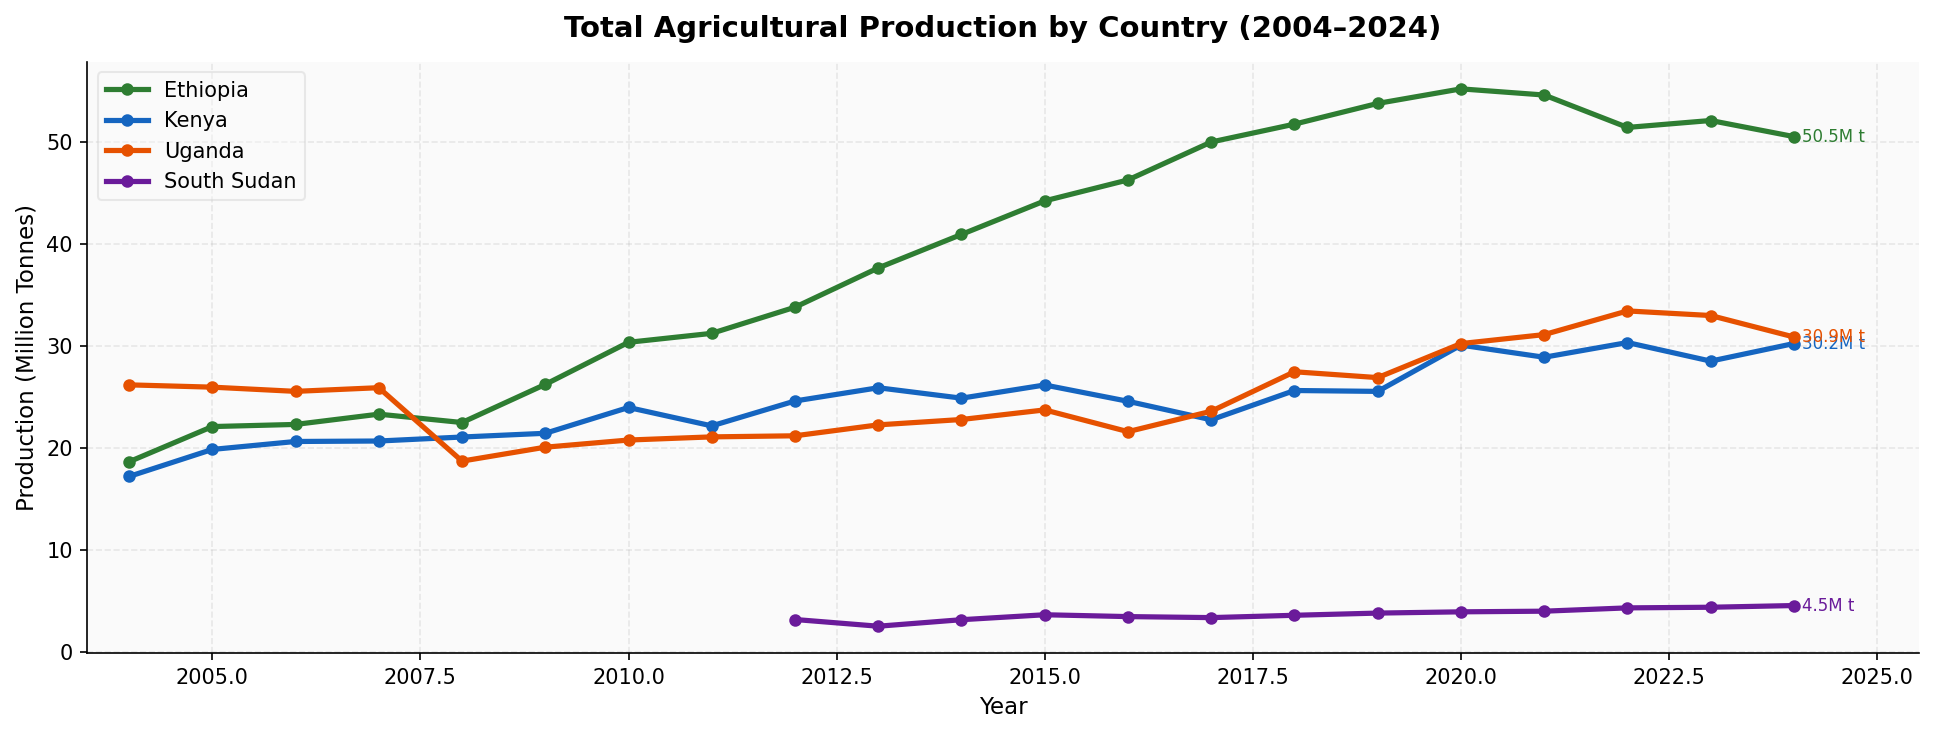<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 2 — Total Agricultural Production by Country, 2004–2024</p>


---
## 5 · Top Crops — 2024 Breakdown
> Maize and Sugar Cane dominate by mass. Uganda leads in Bananas; Ethiopia's diversity reflects broad smallholder agriculture.


In [17]:
data_2024 = (
    prod[prod["Year"]==2024]
    .groupby(["Item","Area"])["Value"].sum()
    .unstack(fill_value=0)
)
top12 = prod[prod["Year"]==2024].groupby("Item")["Value"].sum().nlargest(12).index
result = (data_2024.loc[data_2024.index.isin(top12)] / 1e6).round(2)
result["TOTAL"] = result.sum(axis=1)
result.sort_values("TOTAL", ascending=False).drop("TOTAL",axis=1)


Area,Ethiopia,Kenya,South Sudan,Uganda
Item,,,,
Maize,11.70,4.02,0.16,5.00
Sugar Cane,1.00,9.37,0.00,6.10
Bananas,1.19,2.10,0.00,11.83
Potatoes,4.09,2.19,0.00,0.46
Wheat,6.19,0.31,0.00,0.02
Other Cereals,5.80,0.00,0.00,0.00
Sorghum,4.10,0.24,0.96,0.22
Cassava,0.00,1.21,1.71,1.63
Tea,0.08,2.69,0.00,0.41


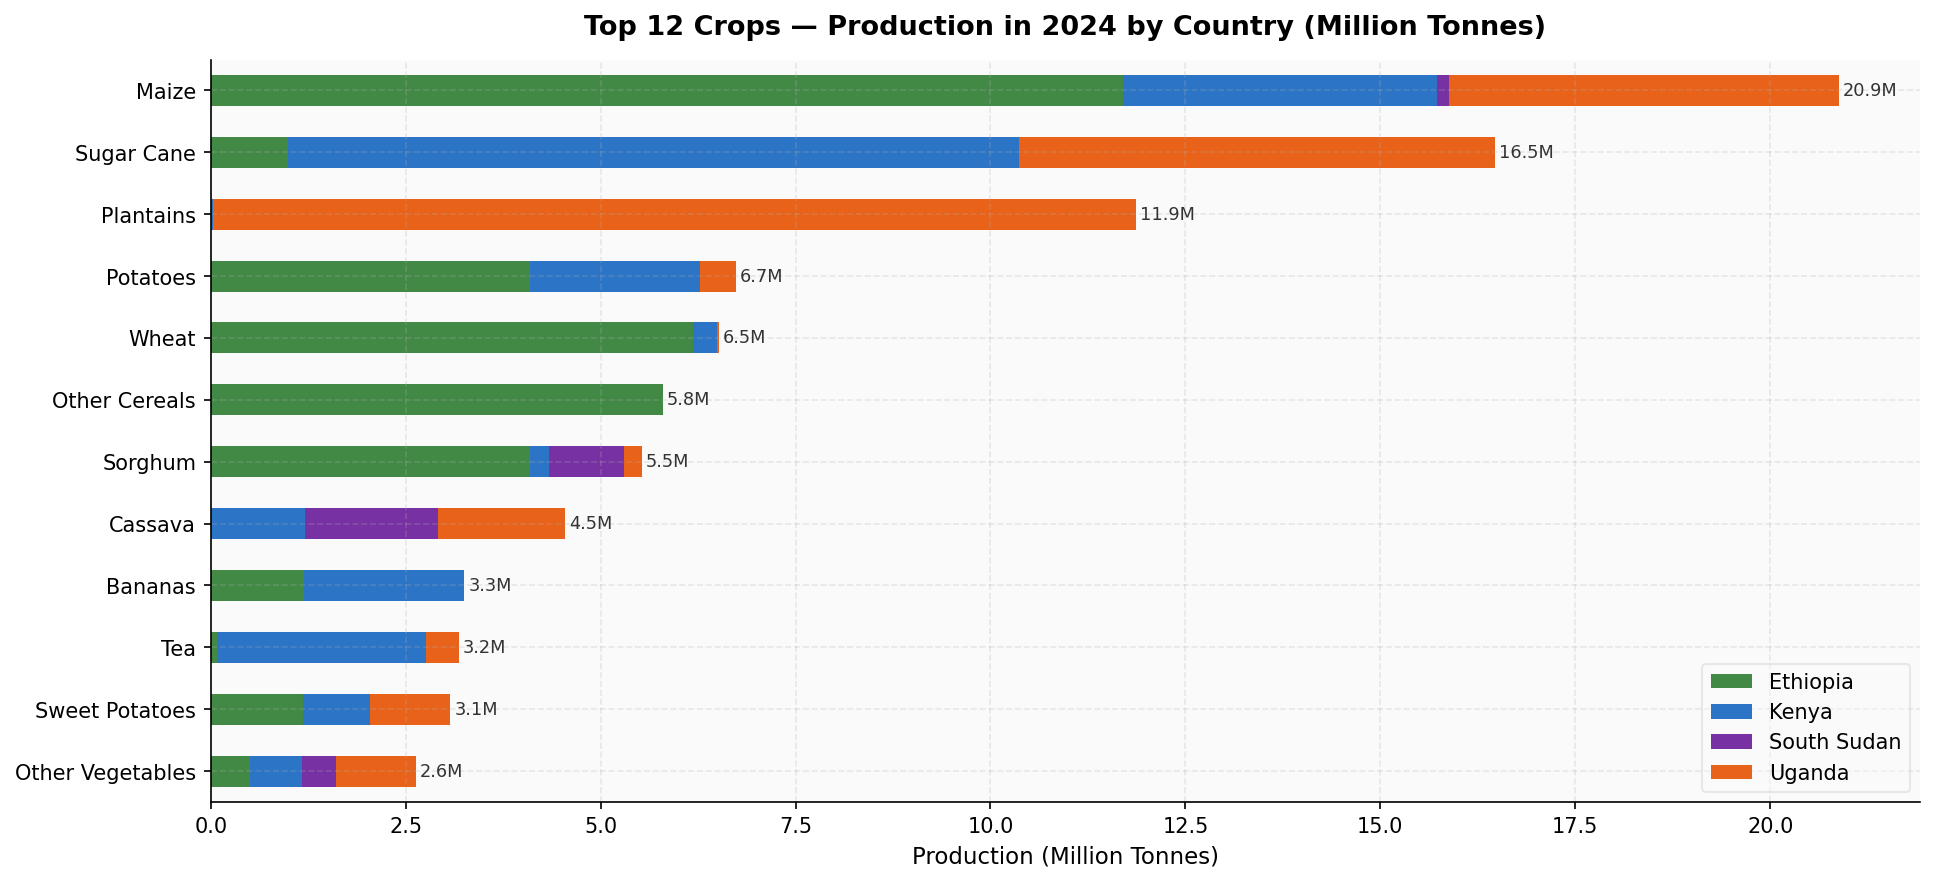<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 3 — Top 12 Crops by Country, 2024 (Million Tonnes)</p>


---
## 6 · Yield Efficiency Heatmap
> **Key finding:** Kenya achieves highest tea yields. South Sudan's yields lag significantly, indicating potential for intensification through better inputs and techniques.


In [19]:
top10_items = prod.groupby("Item")["Value"].sum().nlargest(10).index.tolist()
yld_avg = (
    yld[yld["Item"].isin(top10_items)]
    .groupby(["Item","Area"])["Value"].mean()
    .unstack() / 10000  # kg/ha → t/ha
)
print("Average Yield (t/ha) — Top 10 Crops, full period:")
yld_avg.round(2)


Average Yield (t/ha) — Top 10 Crops, full period:


Area,Ethiopia,Kenya,South Sudan,Uganda
Item,,,,
Bananas,0.89,1.69,NaN,0.48
Cassava,NaN,1.23,1.33,0.54
Maize,0.28,0.16,0.08,0.20
Other Cereals,0.15,NaN,NaN,NaN
Potatoes,1.03,1.42,NaN,0.62
Sorghum,0.22,0.08,0.09,0.11
Sugar Cane,5.32,7.92,NaN,6.94
Sweet Potatoes,2.34,1.27,NaN,0.44
Tea,1.10,0.97,NaN,0.88


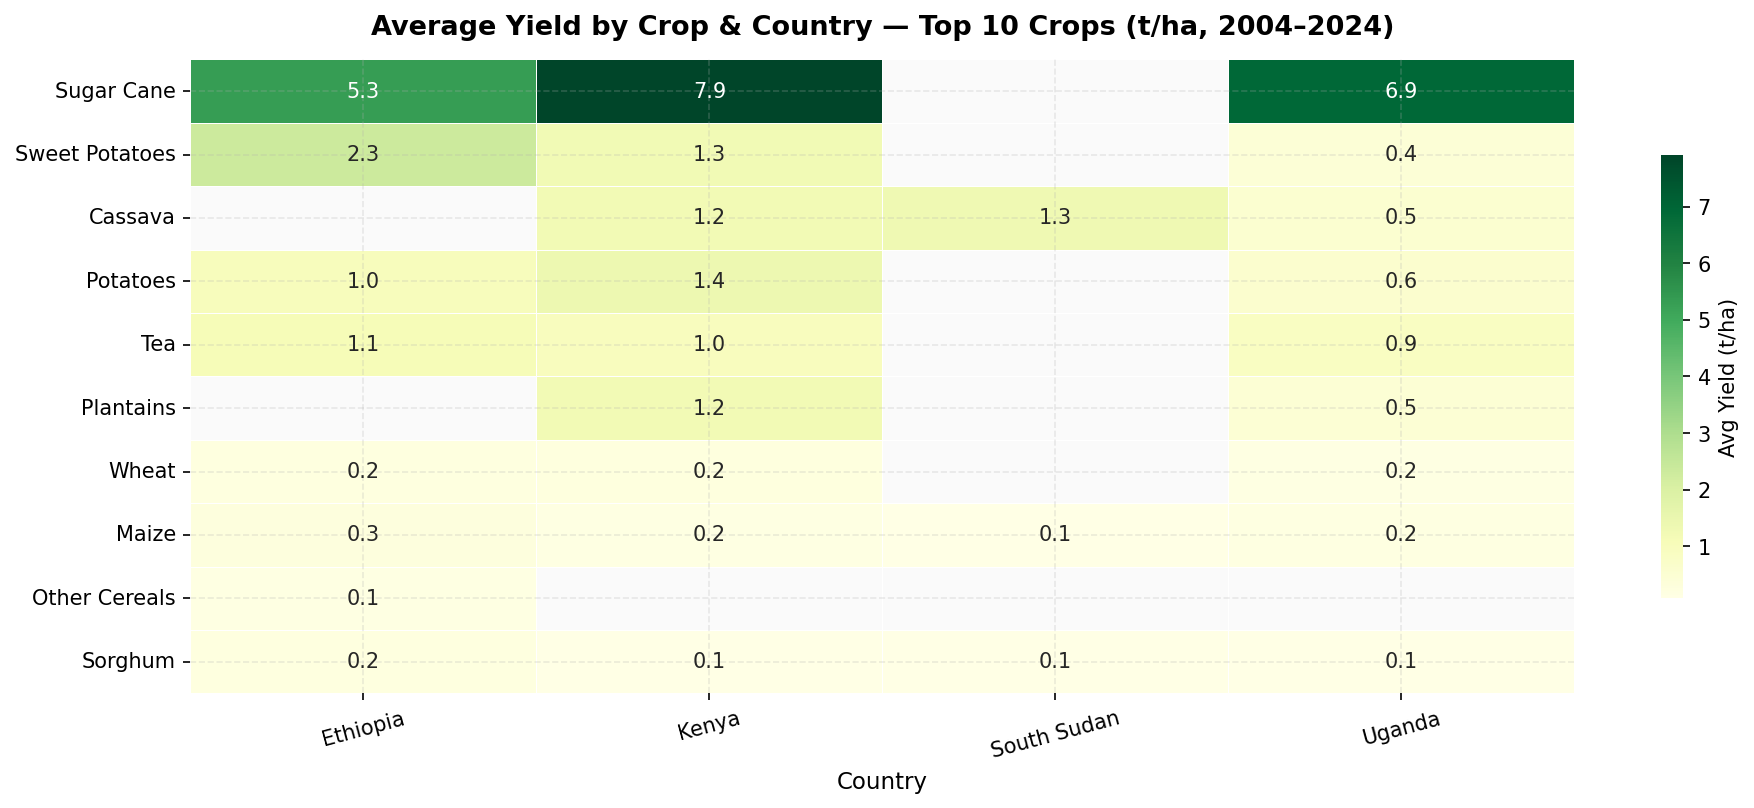<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 4 — Average Yield Heatmap by Crop & Country (t/ha)</p>


---
## 7 · Production Growth Rate (CAGR)
> **CAGR formula:** `(V_end / V_start)^(1/n) − 1`. Reveals which crops are expanding fastest in each country.


In [20]:
top8 = prod.groupby("Item")["Value"].sum().nlargest(8).index.tolist()
rows = []
for item in top8:
    for c in COUNTRIES:
        sub = prod[(prod["Item"]==item)&(prod["Area"]==c)].sort_values("Year")
        if len(sub) >= 3:
            v0,v1 = sub.iloc[0]["Value"], sub.iloc[-1]["Value"]
            n = sub.iloc[-1]["Year"] - sub.iloc[0]["Year"]
            if v0>0 and n>0:
                rows.append({"Crop":item,"Country":c,"CAGR_%":round(((v1/v0)**(1/n)-1)*100,2)})
cagr_df = pd.DataFrame(rows)
cagr_df.pivot(index="Crop",columns="Country",values="CAGR_%").round(2)


Country,Ethiopia,Kenya,South Sudan,Uganda
Crop,,,,
Bananas,9.85,-15.64,NaN,1.01
Cassava,NaN,3.20,4.57,-5.90
Maize,7.21,2.19,1.46,7.96
Other Cereals,5.16,NaN,NaN,NaN
Potatoes,10.97,3.57,NaN,-1.08
Sorghum,4.37,6.46,3.30,-2.82
Sugar Cane,-4.40,3.55,NaN,4.89
Wheat,6.95,-0.97,NaN,2.59


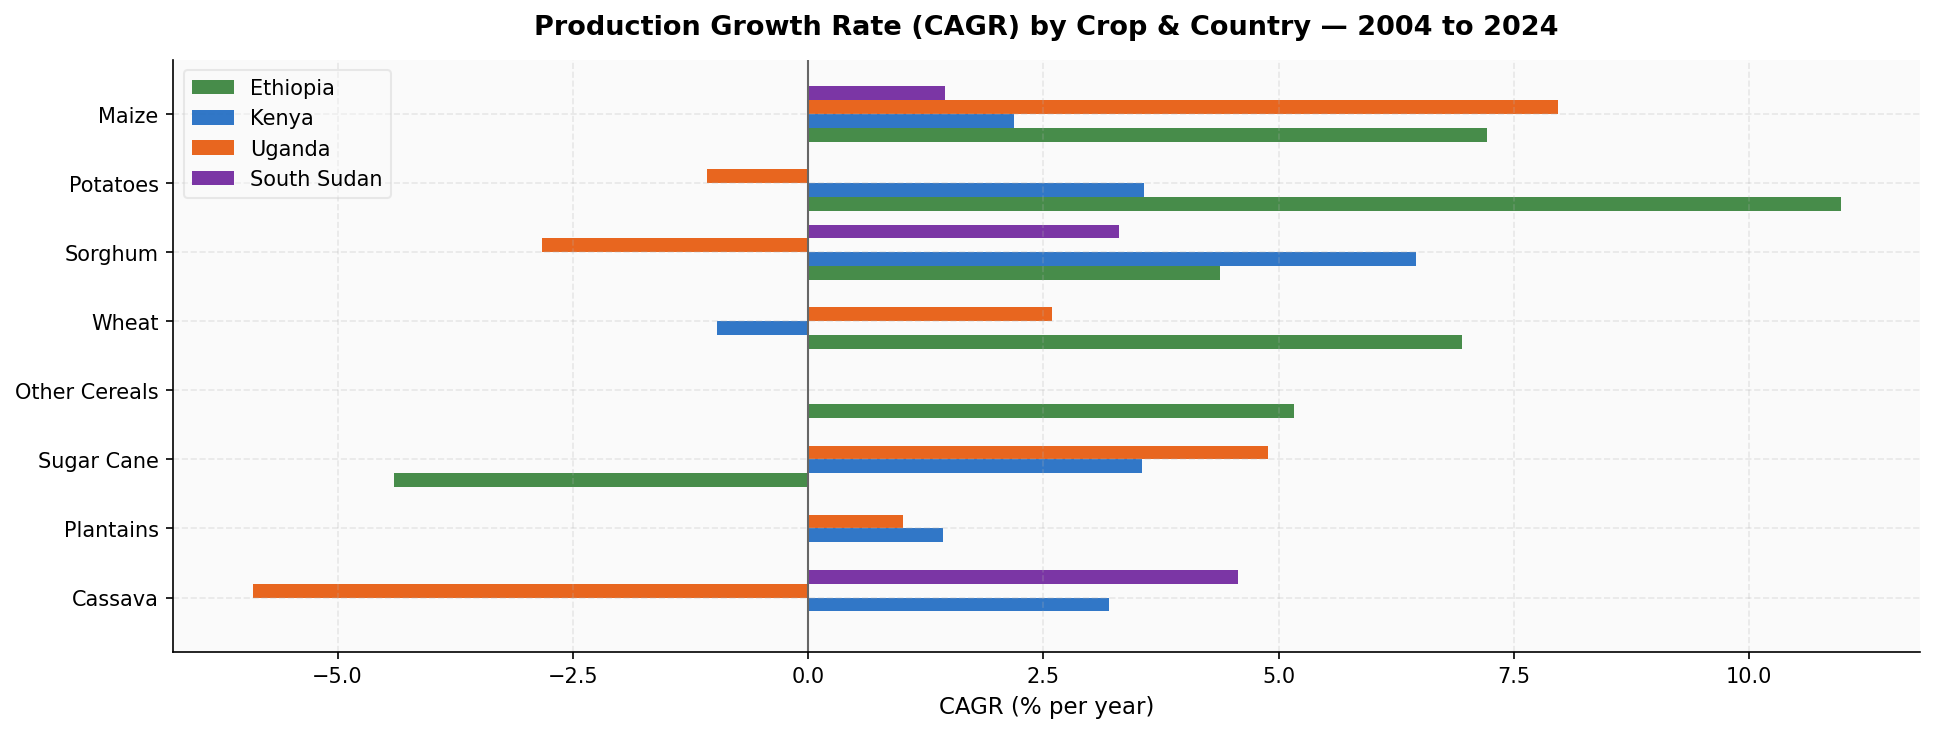<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 5 — CAGR by Crop & Country, 2004–2024</p>


---
## 8 · Area vs Yield — Efficiency Matrix
> Upper-left = high yield, small area (intensive). Lower-right = low yield, large area (extensive). Bubble size = total production.


In [22]:
top15 = prod.groupby("Item")["Value"].sum().nlargest(15).index.tolist()
rng = range(2019,2025)
area_avg = (area[(area["Item"].isin(top15))&(area["Year"].isin(rng))]
            .groupby(["Area","Item"])["Value"].mean()/1e3)  # → 000 ha
yld_avg2 = (yld[(yld["Item"].isin(top15))&(yld["Year"].isin(rng))]
            .groupby(["Area","Item"])["Value"].mean()/10000) # → t/ha
prod_avg = (prod[(prod["Item"].isin(top15))&(prod["Year"].isin(rng))]
            .groupby(["Area","Item"])["Value"].mean()/1e6)   # → Mt
print("2019–2024 averages ready for scatter plot")


2019–2024 averages ready for scatter plot


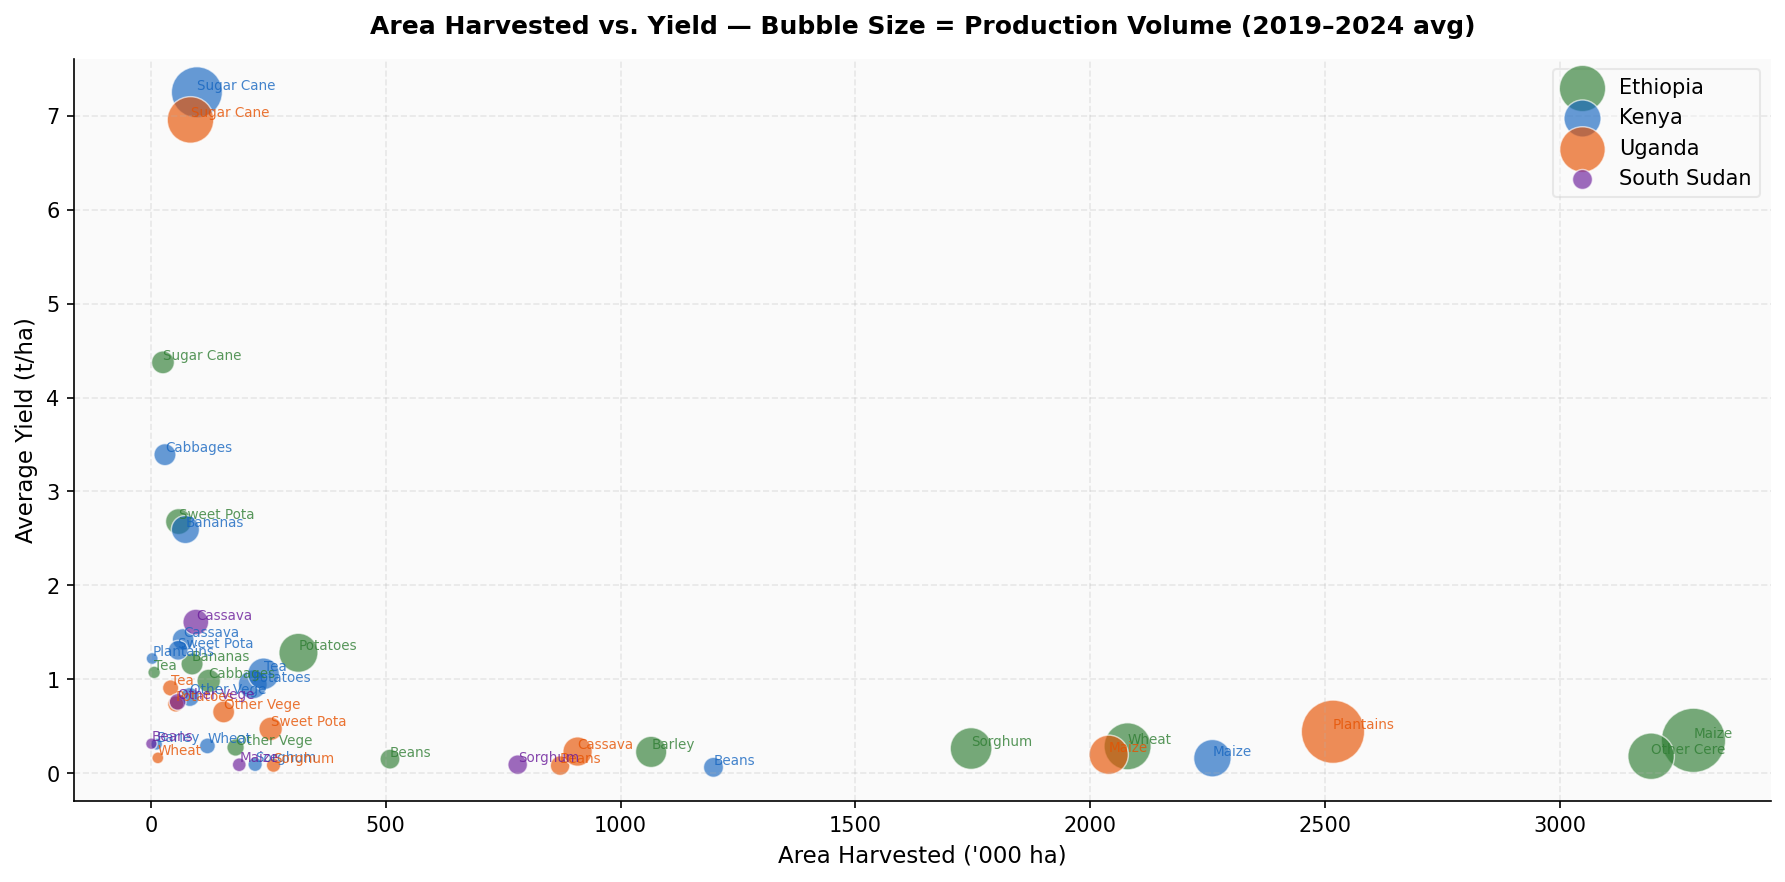<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 6 — Area vs Yield scatter; bubble = production volume (2019–2024 avg)</p>


---
## 9 · High-Value Export Crops: Coffee & Tea
> Ethiopian coffee production has more than **doubled** since 2004. Kenya's tea shows steady incremental growth as a key foreign-exchange earner.


In [23]:
coffee_eth = prod[(prod["Item"]=="Coffee")&(prod["Area"]=="Ethiopia")].sort_values("Year")
tea_ken    = prod[(prod["Item"]=="Tea")&(prod["Area"]=="Kenya")].sort_values("Year")

print(f"Ethiopia Coffee — 2004: {coffee_eth.iloc[0]['Value']/1e3:.0f}k t  →  2024: {coffee_eth.iloc[-1]['Value']/1e3:.0f}k t")
cagr_c = ((coffee_eth.iloc[-1]["Value"]/coffee_eth.iloc[0]["Value"])**(1/20)-1)*100
print(f"   CAGR: {cagr_c:.1f}%/yr")
print(f"Kenya Tea      — 2004: {tea_ken.iloc[0]['Value']/1e3:.0f}k t  →  2024: {tea_ken.iloc[-1]['Value']/1e3:.0f}k t")


Ethiopia Coffee — 2004: 156k t  →  2024: 576k t
   CAGR: 6.7%/yr
Kenya Tea      — 2004: 1411k t  →  2024: 2687k t


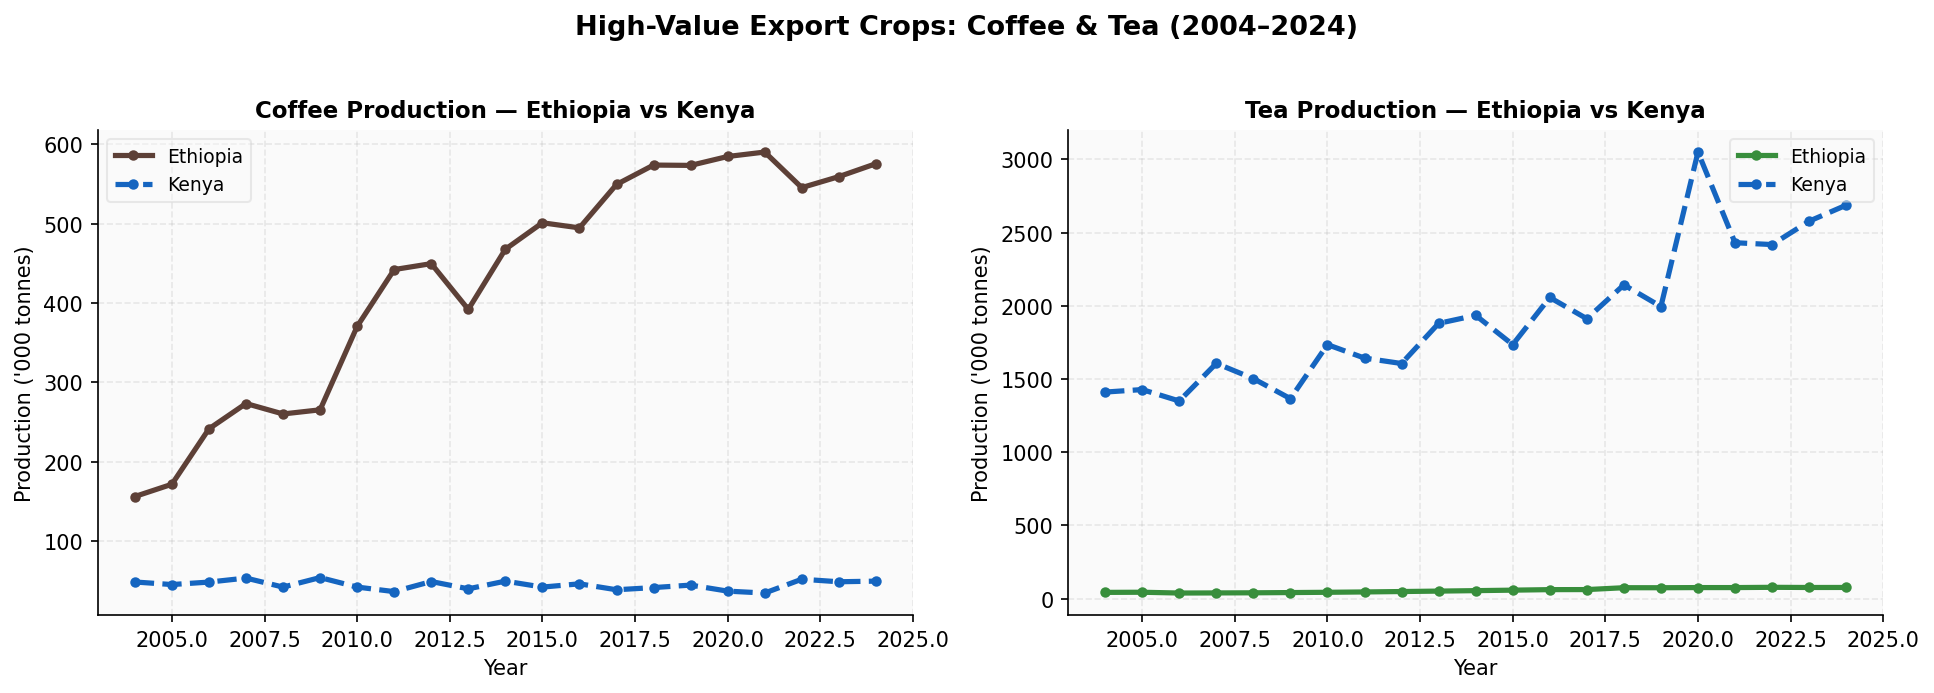<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 7 — Coffee & Tea Production: Ethiopia vs Kenya (2004–2024)</p>


---
## 10 · South Sudan — Food Security Lens
> South Sudan became independent in 2011; civil war erupted in 2013. The stacked area chart directly maps agricultural collapse and partial recovery to these events.


In [24]:
ss_food = ["Sorghum","Maize","Cassava","Beans","Sweet Potatoes","Groundnuts"]
ss = prod[(prod["Area"]=="South Sudan")&(prod["Item"].isin(ss_food))].copy()
ss_pivot = ss.pivot_table(index="Year",columns="Item",values="Value",aggfunc="sum").fillna(0)/1e3
print("South Sudan — Staple Crop Production ('000 t), last 5 years:")
ss_pivot.tail(5).round(1)


South Sudan — Staple Crop Production ('000 t), last 5 years:


Item,Beans,Cassava,Groundnuts,Maize,Sorghum
Year,,,,,
2020,3.9,1425.2,171.1,181.0,631.3
2021,3.8,1499.6,189.8,175.5,591.0
2022,3.9,1599.6,189.8,219.3,759.5
2023,3.9,1637.8,188.9,141.0,867.0
2024,3.9,1709.5,198.4,157.0,960.0


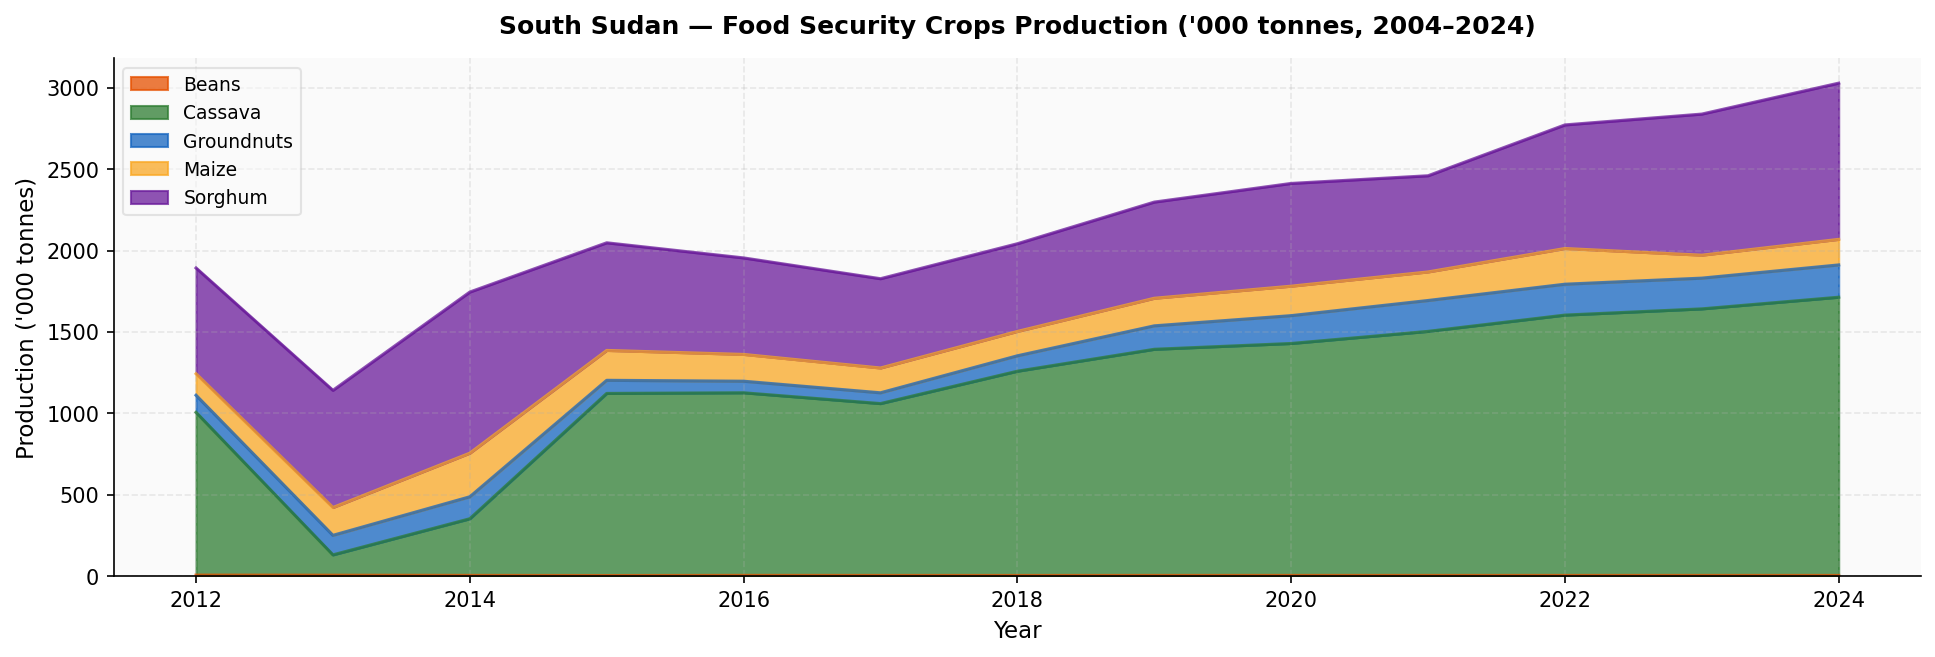<p style="text-align:center;font-size:11px;color:#666;margin-top:4px">Fig 8 — South Sudan Food Security Crops, Stacked Area (2004–2024)</p>


---
## 11 · Key Findings & Recommendations

| # | Finding | Chart |
|---|---------|-------|
| 1 | **Ethiopia leads** — 43% of total 4-country output over 20 years | Fig 1, 2 |
| 2 | **Maize is king** — largest single crop in all countries | Fig 3 |
| 3 | **Yield gaps are large** — South Sudan yields 30–60% below Kenya | Fig 4 |
| 4 | **Coffee doubled** in Ethiopia since 2004 (+3.5%/yr CAGR) | Fig 7 |
| 5 | **Conflict = food insecurity** — South Sudan production collapsed 2013–2016 | Fig 8 |
| 6 | **Kenya's horticulture** achieves high yield on small area — model for intensification | Fig 6 |
| 7 | **Data quality caveat** — ~25% of values are estimated (Flag E); official figures only 1% | EDA |

---
## 12 · Methodology

**Source:** [FAOSTAT](https://www.fao.org/faostat/) Crops & Livestock Products domain  
**Tools:** Python 3 · Pandas · NumPy · Matplotlib · Seaborn  
**Cleaning:** Removed `Flag=M` rows; retained E/I/A/X with caveats; normalised crop names  
**Units:** Production in tonnes (Mt/kt for display), Yield in kg/ha (→ t/ha), Area in hectares  


## Export clean Dataset to Tableau

In [25]:
df.to_csv("east_africa_agriculture_cleaned.csv", index=False)